In [2]:
# import all packages
import pandas as pd
import numpy as np
import glob, os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import math
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm
import geopandas as gpd

### Buildings data

### Surface and Volume from GHSL

In [3]:
# builtarea = ['surface', 'volume']
# reading data from multiple years
def read_Data(path, merged_column_names, builtarea):
    df_merged = pd.DataFrame(columns = ['GEOID'])
    if builtarea == 'surface':
        divideby = 1 # area in sqmeter
    elif builtarea == 'volume':
        divideby = 1000000 # volume in m-Km^2
    else:
        print('Check input format')
        
    merged_column_names.append(builtarea)
    # print(merged_column_names)
    os.chdir(path)
    for file in glob.glob("*.csv"):
        df = pd.read_csv(file, dtype={'GEOID':str})
        df['TOTALAREA_SQKM'] = df[['ALAND', 'AWATER']].sum(axis=1)/1000000
        df[builtarea] = df['sum']/divideby
        df = df.sort_values(by='GEOID').reset_index(drop=True)
        # print(df.columns)
        print('Shape of the dataframe:', df.shape, 'and Total built area (volume) in squaremeters (m-Km^2): ', df[builtarea].sum())
        df_merged = df_merged.merge(df, on='GEOID', suffixes = ('', file[16:-4]), how = 'outer')

    return df_merged

In [4]:
surface_path = r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\Surface\\'
volume_path = r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\Volume\\'

column_names = ['GEOID', 'NAMELSAD', 'sum']

df_surface = read_Data(surface_path, column_names, 'surface')
df_volume = read_Data(volume_path, column_names, 'volume')

Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m-Km^2):  21644923940.827446
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m-Km^2):  24308169725.54902
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m-Km^2):  27090809701.21176
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m-Km^2):  30132932830.333332
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m-Km^2):  34211558949.564705
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m-Km^2):  36204795388.78432
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m-Km^2):  37375579106.32157
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m-Km^2):  157313.24840056078
Shape of the dataframe: (32188, 8) and Total built area (volume) in squaremeters (m-Km^2):  173143.43487209803
Shape

In [5]:
# df_volume.filter(regex=("volume*")).columns # '1714000'
# 168.465656 - 121.339918
# df_volume[['GEOID', 'NAMELSAD', 'volume', 'volume_1990', 'volume_1995', 'volume_2000', 'volume_2010', 'volume_2015', 'volume_2020']]

In [6]:
# To check the consecuate changes in area/ volumne in each 10 yr interval
df_surface['change_80_90'] = (df_surface['surface_1990'] - df_surface['surface'])
df_surface['change_90_00'] = (df_surface['surface_2000'] - df_surface['surface_1990'])
df_surface['change_00_10'] = (df_surface['surface_2010'] - df_surface['surface_2000'])
df_surface['change_10_20'] = (df_surface['surface_2020'] - df_surface['surface_2010'])

df_volume['Vchange_80_90'] = (df_volume['volume_1990'] - df_volume['volume'])
df_volume['Vchange_90_00'] = (df_volume['volume_2000'] - df_volume['volume_1990'])
df_volume['Vchange_00_10'] = (df_volume['volume_2010'] - df_volume['volume_2000'])
df_volume['Vchange_10_20'] = (df_volume['volume_2020'] - df_volume['volume_2010'])

### Non residential buildings data from GHSL for the year 2020

In [7]:
df_non_res = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\Non_res_surface\BuiltArea_GHSL_S_nres_2020.csv')
df_non_res['GEOID'] = df_non_res['GEOID'].astype(str).str.rjust(7, '0')
df_non_res.rename(columns = {'sum':'surface_nonRes_2020'}, inplace= True)
df_non_res.columns

Index(['STATEFP', 'GEOID', 'NAMELSAD', 'ALAND', 'AWATER',
       'surface_nonRes_2020'],
      dtype='object')

### Merge built are with nonResidential: Find residential only

In [8]:
# Merge surface with volume and non residential
# Here surface refers to total building are: res + non-res
df = df_volume.merge(df_surface[['GEOID','surface', 'surface_1990', 'surface_1995', 'surface_2000', 'surface_2010', 'surface_2015', 'surface_2020',
                                 'change_80_90', 'change_90_00', 'change_00_10', 'change_10_20']], on = 'GEOID')
df = df.merge(df_non_res[['GEOID', 'surface_nonRes_2020']], on ='GEOID')
df['surface_Res_2020'] = df['surface_2020'] - df['surface_nonRes_2020']

## Save the clean data to avoid the merging and combining again and again

# df_selected = df[['GEOID', 'TOTALAREA_SQKM_2020', 'surface', 'surface_1990', 'surface_1995', 'surface_2000', 'surface_2010', 'surface_2015', 'surface_2020',
#                    'surface_nonRes_2020','surface_Res_2020', 'volume', 'volume_1990', 'volume_1995', 'volume_2000', 'volume_2010', 'volume_2015', 'volume_2020', 
#                    'Vchange_80_90', 'Vchange_90_00', 'Vchange_00_10', 'Vchange_10_20', 'change_80_90', 'change_90_00', 'change_00_10', 'change_10_20']]

# df_selected.to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\area_vol_clean\GHSL_AREA_VOL_cleaned.csv')

In [9]:
print("Number of missing values in built area data: ===")
df.isna().sum().sum()

Number of missing values in built area data: ===


0

### Read places geometry from shapefile

In [10]:
os.environ['USE_PYGEOS'] = '0'
# Import places map
places_US = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\MapData\all_places\compiled.shp')
print('Total no of places in the US:===')
print(places_US.shape)

# Exclude states that do not have consistent data for roadways
places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]
print('No of places in the 50 states:===')
print(places_50_states.shape)

Total no of places in the US:===
(32188, 17)
No of places in the 50 states:===
(31262, 17)


### Join surface volume with geometry

In [11]:
df_with_geom = places_50_states.merge(df[['GEOID', 'surface_2020','surface_Res_2020', 'surface_nonRes_2020', 'volume_2020']], on = 'GEOID')
df_with_geom.columns
df_with_geom = df_with_geom.to_crs('EPSG:9311')
print(df.shape, df_with_geom.shape)

(32188, 67) (31262, 21)


In [12]:
# # PLOT THE ATTRIBUTES
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14.27,5.27))
# for ax in axes.flatten():
#     continental_ax = ax          
#     # Set bounds to fit desired areas in each plot for epsg 9311
#     continental_ax.set_xlim(-2257388.37, 2695859.75)
#     continental_ax.set_ylim(-2546944.04, 808080.9)
#     df_with_geom.plot(column = 'change_10_20', 
#              ax=continental_ax,
#              legend = True)

In [13]:
# Area of the place in sqkm
df_with_geom['landAreaSqkm'] = df_with_geom['ALAND']/1000000
# Percent of total area that has buildings
df_with_geom['percent_built_surface'] = df_with_geom['surface_2020'] * 100/df_with_geom['ALAND']

df_with_geom.isna().sum().sum()

0

### Add housing units and age from ACS

In [14]:
df_YearBuilt = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\Housing Data ACS\HousingDataCleaned.csv', index_col = 0)
df_YearBuilt['GEOID'] = df_YearBuilt['GEOID'].str[9:]

In [15]:
df_YearBuilt_selected = df_YearBuilt[['GEOID', ' !!Total:', 'HUs_occupied', 'HUs_vaccant', 'NAME', 'HUs_Total', 'YB_>=_2020', 'YB_2010_2019', 'YB_2000_2009',
               'YB_1980_1999', 'YB_1960_1979', 'YB_1940_1959', 'YB_<=_1939','Year_Built', 'Percent_Built']]

### Merge with surface-volume with HUs and age

In [16]:
df_buildings = df_with_geom.merge(df_YearBuilt_selected, on = 'GEOID')
# df_buildings.columns

In [17]:
# missing valus in the year-built data
df_buildings[df_buildings['Year_Built'].isnull()][['GEOID', ' !!Total:', 'HUs_occupied', 'HUs_vaccant',  'HUs_Total']] #['STATEFP'].value_counts().sum() 

,GEOID,!!Total:,HUs_occupied,HUs_vaccant,HUs_Total
480,0112544,34,19,15,0.0
499,0126152,44,44,0,0.0
534,0147848,36,23,13,0.0
565,0165784,21,21,0,0.0
571,0170632,58,51,7,0.0
...,...,...,...,...,...
31228,5659332,2,2,0,0.0
31232,5662305,19,19,0,0.0
31239,5666655,37,31,6,0.0
31248,5675355,0,0,0,0.0


In [18]:
# get an weighted age for each place 
df_buildings['weighted_avg_age'] = ((2024-1939)*df_buildings['YB_<=_1939'] + (2024-1950)*df_buildings['YB_1940_1959'] + (2024-1970)*df_buildings['YB_1960_1979'] +
                                  (2024-1990)*df_buildings['YB_1980_1999'] + (2024-2004)*df_buildings['YB_2000_2009'] + (2024-2014)*df_buildings['YB_2010_2019'] + 
                                  (2024-2022)*df_buildings['YB_>=_2020'])/100

df_buildings[['STATEFP', 'NAMELSAD','YB_>=_2020','YB_2010_2019', 'YB_2000_2009', 'Year_Built', 'Percent_Built', 'weighted_avg_age']].isna().sum()

STATEFP               0
NAMELSAD              0
YB_>=_2020          489
YB_2010_2019        489
YB_2000_2009        489
Year_Built          489
Percent_Built       489
weighted_avg_age    489
dtype: int64

# Import population and attributes data from depopulation study

In [19]:
df_population = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\forecasted_trend.csv', index_col  = 0)
df_population['GEOID'] = df_population['GEOID'].astype(str).str.rjust(7,'0')

df_attributes = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\df_attributes.csv', index_col  = 0)
df_attributes['GEOID'] = df_attributes['GEOID'].astype(str).str.rjust(7,'0')

df_pop_attr = df_population.merge(df_attributes[['GEOID', 'REGION', 'city type', 'weighted_HU_density_sqmi',
                                                 'ua-to-place allocation factor_max', 'population_ua_min',
                                                 'population_ua_max']], on = 'GEOID')

In [20]:
df_attributes.shape, df_population.shape

((31908, 33), (31617, 58))

In [21]:
# Total population for SSP 2 for each 10 yr interval
print('Total population in millions for 51 states: ===')
df_population[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000

Total population in millions for 51 states: ===


CensusPop_20    249.755152
ssp22020        250.994929
ssp22030        271.282551
ssp22040        289.394587
ssp22050        305.168766
ssp22060        320.539073
ssp22070        334.443119
ssp22080        344.689135
ssp22090        350.775132
ssp22100        353.489903
dtype: float64

### How many places fluctuate between increase and decrease

In [22]:
# Total fluctuations in population over time
diff_population = df_population[['ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].diff(axis=1)
diff_wo_NAN = diff_population.drop(columns=['ssp22020']).dropna()
diff_wo_NAN
print("Changes in population over time: =====\n")
print("Time in Year")
print("  20~30  30~40  40~50  50~60  60~70  70~80  80~90  90~100")
print(np.where(diff_wo_NAN >= 0, 1, -1).sum(axis=0))

population_change_dir = np.where(diff_wo_NAN >= 0, 1, -1).sum(axis=1)

consistent, at_leat_one_fulctuation = 0, 0
# iterating each number in list
for num in population_change_dir:
     # checking condition
    if -8 < num < 8:
        at_leat_one_fulctuation += 1 
    else:
        consistent += 1
 
print("At least one fluctuation: ", at_leat_one_fulctuation)
print("Consistent increase of decrease: ", consistent)
print('\n')

print('Values in each group:==')
np.array(np.unique(population_change_dir, return_counts=True)).T

Changes in population over time: =====

Time in Year
  20~30  30~40  40~50  50~60  60~70  70~80  80~90  90~100
[  7624   1830  -1416    368   -748  -4580  -9574 -14018]
At least one fluctuation:  12479
Consistent increase of decrease:  19089


Values in each group:==


array([[   -8, 11031],
       [   -6,  2739],
       [   -4,  1557],
       [   -2,   823],
       [    0,   708],
       [    2,  1782],
       [    4,  2603],
       [    6,  2267],
       [    8,  8058]], dtype=int64)

# Merge buildings with population

In [23]:
building_with_pop = df_buildings.merge(df_pop_attr[['GEOID', 'State', 'REGION', 'ua-to-place allocation factor_max', 'population_ua_min',
                                                    'population_ua_max', 'CensusPop_20', 'city type','weighted_HU_density_sqmi',
                                                   'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080',
                                                   'ssp22090','ssp22100']], on = 'GEOID', how='left')

In [24]:
building_with_pop[building_with_pop['GEOID'].str.startswith('214800')][['GEOID', 'NAMELSAD','CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050']]
# 2010 Census
# Louisville/Jefferson County metro government (balance), Kentucky	597337
# 2020 Census
# Louisville city, Kentucky	246161
# Louisville/Jefferson County metro government (balance), Kentucky	386884

# 246161+386884 = 633045

,GEOID,NAMELSAD,CensusPop_20,ssp22020,ssp22030,ssp22040,ssp22050
10251,2148006,Louisville/Jefferson County metro government (...,386884.0,389068.4372,424417.2341,456660.9352,485264.1312
10411,2148000,Louisville city,NaN,NaN,NaN,NaN,NaN


In [25]:
building_with_pop.shape, df_buildings.shape, df_population.shape, df_attributes.shape

((31262, 55), (31262, 38), (31617, 58), (31908, 33))

In [26]:
building_with_pop[building_with_pop['city type'] == 'not enough data'].head() #shape[0] # ['CensusPop_20'].sum()

,STATEFP,PLACEFP,PLACENS,GEOID,NAME_x,NAMELSAD,LSAD,CLASSFP,PCICBSA,PCINECTA,...,weighted_HU_density_sqmi,ssp22020,ssp22030,ssp22040,ssp22050,ssp22060,ssp22070,ssp22080,ssp22090,ssp22100
812,04,28985,02582791,0428985,Grand Canyon West,Grand Canyon West CDP,57,U2,N,N,...,0.802321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
987,04,71230,02410036,0471230,Supai,Supai CDP,57,U1,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2940,06,56182,02409040,0656182,Paxton,Paxton CDP,57,U1,N,N,...,2.384482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3101,06,71932,02585449,0671932,Silver City,Silver City CDP,57,U1,N,N,...,1.637337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3202,06,81312,02583172,0681312,University of California-Merced,University of California-Merced CDP,57,U1,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
building_with_pop.groupby('city type')[['Percent_Built','weighted_HU_density_sqmi']].describe()

Percent_Built                                               \
                        count       mean        std   min      25%     50%   
city type                                                                    
not enough data          13.0  91.038462  17.244107  53.8  100.000  100.00   
periurban              5692.0  42.807344  13.306884  19.3   33.400   39.90   
rural                 17897.0  46.906766  17.019556  19.2   34.900   42.40   
suburban               6859.0  41.341260  12.072221  18.4   32.600   39.00   
urban                   312.0  42.549679  11.208974  20.8   34.775   41.05   

                                weighted_HU_density_sqmi               \
                     75%    max                    count         mean   
city type                                                               
not enough data  100.000  100.0                      9.0     3.560957   
periurban         48.900  100.0                   5714.0   559.901746   
rural             54.200  100.0                  18266.0    33.077109   
suburban          47.500  100.0                   6887.0   952.962411   
urban             48.725   90.7                    312.0  6216.890065   

                                                                     \
                         std          min          25%          50%   
city type                                                             
not enough data     3.818755     0.758201     1.365051     2.005371   
periurban         691.460189     0.150793   102.861311   277.404535   
rural             104.905921     0.033770     5.282970    13.578384   
suburban          862.217631     0.000000   261.267104   719.935567   
urban            3912.153516  3018.272827  4259.693215  4958.075743   

                                            
                         75%           max  
city type                                   
not enough data     3.758055     12.335230  
periurban         745.584636   5904.184022  
rural              32.031800   5369.562100  
suburban         1418.670632  10742.379990  
urban            6775.948549  30707.800203

In [28]:
# building_with_pop[[' !!Total:', 'HUs_occupied', 'HUs_vaccant','HUs_Total',]].sum()

In [29]:
condition = building_with_pop[' !!Total:'] != 0
building_with_pop.loc[condition,'avg_HU_size_sqm'] = (building_with_pop['surface_2020'] / building_with_pop[' !!Total:'])
building_with_pop.loc[condition,'HU_density_sqmile'] = building_with_pop[' !!Total:'] / (3.86102e-7 * building_with_pop['ALAND'])
print(building_with_pop.shape)

building_with_pop.loc[condition,'avg_HU_size_Res_sqm'] = (building_with_pop['surface_Res_2020'] / building_with_pop[' !!Total:'])

(31262, 57)


In [30]:
print('Total NaNs in population and built area:===')
print(building_with_pop[['CensusPop_20', 'ssp22040', 'surface_Res_2020']].isna().sum())
print("Places with no built area:===", building_with_pop[building_with_pop['surface_Res_2020'] == 0].shape[0])
print("Places with zero population in census 2020:===", building_with_pop[building_with_pop['CensusPop_20'] == 0].shape[0])
print("Places with no available population forecast:===", building_with_pop[building_with_pop['ssp22040'].isnull()].shape[0])

Total NaNs in population and built area:===
CensusPop_20         1
ssp22040            44
surface_Res_2020     0
dtype: int64
Places with no built area:=== 3
Places with zero population in census 2020:=== 43
Places with no available population forecast:=== 44


In [31]:
building_clean = building_with_pop.dropna(subset=['CensusPop_20', 'ssp22040', 'surface_Res_2020']).reset_index(drop=True)
print("Shape of the clean dataset with nonzero values:==")
building_clean.shape

Shape of the clean dataset with nonzero values:==


(31218, 58)

### Fit linear reg

In [32]:
def find_scale_parameters(df, infra_col, pop_col):
    df.loc[:,'log_pop_col'] = np.log(df[pop_col].astype(float))
    df.loc[:, 'log_infra_col'] = np.log(df[infra_col].astype(float))

    # fig = px.scatter(df, x='log_pop_col', y='log_infra_col', hover_data=['GEOID', 'NAMELSAD'],
    #                 width=800, height=800) 
    # fig.show()
    # Check plot how the log-log plot looks?
    sns.regplot(x='log_pop_col', y='log_infra_col', data=df, 
                y_jitter=.03, ci =None, scatter_kws={"s": 1})
    x = df['log_pop_col']
    y = df['log_infra_col']

    #run anova model to find confidence intervals
    # Fit the regression model
    model = sm.ols("y ~ x", data={"y": y, "x": x}).fit()

    # Display regression summary
    print(model.summary())
    print(model.params)
    # Calculate confidence intervals using ANOVA
    anova_result = anova_lm(model)
    conf_int = model.conf_int(alpha=0.05, cols=None)

    # Display ANOVA results and confidence intervals
    print("\nConfidence Intervals: 'log(a)' and 'b' values---")
    print(conf_int)
    intercepts = [conf_int.iloc[0][0], conf_int.iloc[0][1]]
    beta = [conf_int.iloc[1][0], conf_int.iloc[1][1]]
    model_params = model.params
    return intercepts, beta, model_params

### Model comparision Pruned Nonpruned F_test

In [33]:
building_with_pop['per_cap_mass_20'] =  building_with_pop['surface_Res_2020'] / building_with_pop['CensusPop_20']
building_with_pop['avg_HU_size_sqm_Res'] = building_with_pop['surface_Res_2020'] / building_with_pop['HUs_Total']
stocks_with_pop = building_with_pop[building_with_pop['CensusPop_20'] != 0]
stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'suburban']
print(stocks_with_pop.shape)

infra_col ='surface_Res_2020'
pop_col = 'CensusPop_20'
df = stocks_with_pop.copy()


### ============== PRUNING ============== ###
# Set the threshold to the 90th percentile
threshold = df[infra_col].quantile(0.9)
# Filter the DataFrame to include only points in the to 10%
df_pruned = df[df[infra_col] > threshold]
print(df_pruned.shape)

y = np.log(df[infra_col].astype(float))
x = np.log(df[pop_col].astype(float))

y_pruned = np.log(df_pruned[infra_col].astype(float))
x_pruned = np.log(df_pruned[pop_col].astype(float)) 

m01 = sm.ols("y ~ x", data={"y": y, "x": x}).fit()
m02 = sm.ols("y_pruned ~ x_pruned", data={"y_pruned": y_pruned, "x_pruned": x_pruned}).fit()
anova_results= anova_lm(m01, m02)
print(anova_results)
print('\n')

if anova_results['Pr(>F)'][1] < 0.005:
    print(f"Since {anova_results['Pr(>F)'][1]} < 0.005, difference is significant")
    print("Built seperate models")


(6887, 60)
(689, 60)
   df_resid          ssr  df_diff      ss_diff         F        Pr(>F)
0    6885.0  1144.100817      0.0          NaN       NaN           NaN
1     687.0    46.975224   6198.0  1097.125593  2.588765  1.315020e-49


Since 1.3150197780850795e-49 < 0.005, difference is significant
Built seperate models


In [34]:
# df_pruned[infra_col].describe(), df[infra_col].describe()

#### Plot different a and b s for check

In [35]:
# # Set the seed for reproducibility (optional)
# np.random.seed(42)

# # Generate random x-values
# num_points = 50
# x = np.random.rand(num_points)

# # Define multiple sets of a and b values
# params = [(8.0, 0.8), (0.8, 0.8), (-8.0, 0.8),
#           (-8.0, 4.5), (-8, 1), (-8, -0.5)]

# # Create subplots
# fig, axs = plt.subplots(len(params), figsize=(5, 16), sharex=True, sharey=True)

# # Plot the points and fitting lines for each set of parameters in subplots
# for i, (a, b) in enumerate(params):

#     # Calculate corresponding y-values based on the relation Y = a * X^b
#     y = a * np.power(x, b)    
#     # Add some random noise to y-values (optional)
#     noise_factor = 0.2
#     y += np.random.normal(0, noise_factor, num_points)
#     # Plot the points
#     axs[i].scatter(x, y, label=f'a={a}, b={b}')
#     # Fit a polynomial to the data and plot the fitting line
#     degree = 1  # degree of the polynomial (1 for a linear fit)
#     coeffs = np.polyfit(x, y, degree)
#     fitted_line = np.poly1d(coeffs)
#     x_vals_for_fitting_line = np.linspace(0, 1, 100)
#     y_vals_for_fitting_line = fitted_line(x_vals_for_fitting_line)
# #     axs[i].plot(x_vals_for_fitting_line, y_vals_for_fitting_line, linestyle='--', label=f'Fit: a={coeffs[0]:.2f}, b={coeffs[1]:.2f}')

#     # Set title for each subplot
#     axs[i].set_title(f'Subplot {i+1}')
#     axs[i].legend()

# # Customize the plot
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# fig.suptitle('Random Points with Y = a * X^b Relation and Fitting Lines in Subplots')

# # Adjust layout to prevent clipping of titles
# plt.tight_layout(rect=[0, 0, 1, 1])

# # Show the plot
# plt.show()

#### Fit the model for each city type

In [36]:
pd.set_option('mode.chained_assignment', None) # To stop SettingWithCopy warning
list_of_city_types = ['urban', 'suburban', 'periurban', 'rural']

def find_next_stock(df, current_stock_col, current_pop_col, next_pop_col, citytype):
    print(f"Initial dataframe:====")
    print(df.shape)
    
    df_stocks_iter = pd.DataFrame()
    
    df['per_cap_mass_t1'] = df[current_stock_col] / df[current_pop_col]
    df_nonzero = df[df[current_pop_col] !=0]
    df_nonzero_city = df_nonzero[df_nonzero['city type'] == citytype]
    print(f"Shape of the dataframe for {citytype}:====")
    print(df_nonzero_city.shape)
    

    print("Prune upper and lower 10 percent data before fitting to the scaling law")
    print("***DEFINITELY NEED TO VALIDATE THIS PRUNING***")
    ### ============== PRUNING ============== ### top and bottom 10 %
    # Set the threshold to the 90th percentile
    threshold_upper = df_nonzero_city[current_stock_col].quantile(0.9)
    threshold_lower = df_nonzero_city[current_stock_col].quantile(0.1)
    # Filter the DataFrame to include only points in the to middle 80%
    df_for_fitting = df_nonzero_city[df_nonzero_city[current_stock_col] < threshold_upper]
    df_for_fitting = df_nonzero_city[df_nonzero_city[current_stock_col] > threshold_lower]
    print("Shape of dataframe used in scaling fit:===")
    print(df_for_fitting.shape)

    # Fit the log-log linear model
    x = find_scale_parameters(df_for_fitting, infra_col= current_stock_col, pop_col = current_pop_col)

    # Get the model parameters
    # Set the range for the uniform distribution
    log_a_lower = x[0][0]
    log_a_upper= x[0][1]

    beta_lower = x[1][0]
    beta_upper= x[1][1]

    print("Using the coefficient found from scaling law for the complete dataframe:===")
    # Create an empty column of stocks at next time step
    df_nonzero_city.loc[:,'stock_at_t2'] = np.nan
    df_nonzero_city.loc[:,'stocks_at_reg'] = np.nan

    df_stocks_iter = df_nonzero_city[['GEOID', 'NAMELSAD']]

    # Randomly sample loga and beta values
    def sample_coeff():
        beta = np.random.choice(beta_uniform, size=1)
        return beta

    for i in range(10):
        # Sampling coefficient beta from and uniform distribution
        beta_uniform = np.random.uniform(low=beta_lower, high=beta_upper, size=100000)     
        for index, row in df_nonzero_city.iterrows():
            beta = sample_coeff()
            # IF loga CHNAGES WITH EACH TIME STEP
            log_a = np.log(row[current_stock_col] / row[current_pop_col])
            # IF loga IS CONSTANT WITH EACH TIME STEP
            # log_a = np.log(row['surface_2020'] / row['CensusPop_20'])
            # print(log_a, beta)
            df_nonzero_city.at[index,'stocks_at_reg'] = np.exp(log_a) * (row[current_pop_col] ** beta)
            if row[next_pop_col] >= row[current_pop_col]:
                df_nonzero_city.at[index,'stocks_at_t2'] = np.exp(log_a) * (row[next_pop_col] ** beta)
            else:
                df_nonzero_city.at[index,'stocks_at_t2'] = 0

        df_nonzero_city.loc[:,'added_stock'] = np.where(df_nonzero_city['stocks_at_t2'] == 0, 0, (df_nonzero_city['stocks_at_t2'] - df_nonzero_city['stocks_at_reg']))
        df_nonzero_city.loc[:,'stock_next_time_step'] = (df_nonzero_city[current_stock_col] + df_nonzero_city['added_stock'])
        df_nonzero_city.loc[:,'per_cap_mass_next_time_step'] = (df_nonzero_city[current_stock_col] + df_nonzero_city['added_stock'])/df_nonzero_city[next_pop_col] 

        df_stocks_iter = pd.concat([df_stocks_iter, df_nonzero_city[['per_cap_mass_next_time_step', 'stock_next_time_step']]], axis=1)

    return df_stocks_iter

In [37]:
building_clean = building_with_pop.dropna(subset=['CensusPop_20', 'ssp22040', 'surface_Res_2020']).reset_index(drop=True)
print("Shape of the clean dataset with nonzero values:==")
building_clean.shape

Shape of the clean dataset with nonzero values:==


(31218, 60)

### For any t

In [38]:

def process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t):
    print(df_for_analysis.shape)
    # run the fitting model for each city type
    df_2040_urban = find_next_stock(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, list_of_city_types[0])
    df_2040_suburban = find_next_stock(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, list_of_city_types[1])
    df_2040_periurban = find_next_stock(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, list_of_city_types[2])
    df_2040_rural = find_next_stock(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, list_of_city_types[3])

    df_all_types = pd.concat([df_2040_urban, df_2040_suburban, df_2040_periurban, df_2040_rural], axis =0)

    per_cap_mass_at_t = 'per_cap_mass_at_' + str(t)
    surface_Res_at_t = 'surface_Res_at_' + str(t)

    df_all_types[per_cap_mass_at_t] = df_all_types['per_cap_mass_next_time_step'].mean(axis=1)
    df_all_types[surface_Res_at_t] = df_all_types['stock_next_time_step'].mean(axis=1)
    
    df_for_analysis = df_for_analysis.merge(df_all_types[['GEOID', per_cap_mass_at_t, surface_Res_at_t]], on = 'GEOID')

    df_all_types[per_cap_mass_at_t] = df_all_types['per_cap_mass_next_time_step'].mean(axis=1)
    df_all_types[surface_Res_at_t] = df_all_types['stock_next_time_step'].mean(axis=1)

    # building_clean = building_clean.merge(df_all_types[['GEOID', per_cap_mass_at_t, surface_Res_at_t]], on = 'GEOID')

    sqm_to_sqmile = 3.86102e-7 # conversion factor
    
    
    df = df_for_analysis

    HU_density_sqmi_at_t = 'HU_density_sqmi_at_' + str(t)
    HU_density_sqmi_at_t_1 = 'HU_density_sqmi_at_' + str(t-10)
    ua_population_at_t = 'ua_population_at_' + str(t)
    ua_population_at_t_1 = 'ua_population_at_' + str(t-10)
    citytype_at_t = 'citytype_at_' + str(t)
    citytype_at_t_1 = 'citytype_at_' + str(t-10)



    df['change_in_Res_area'] = df[surface_Res_at_t] - df[current_stock_col]
    df['added_HUs_at_t'] = df['change_in_Res_area'] / df['avg_HU_size_Res_sqm']

    if current_stock_col == 'surface_Res_2020':
        df[HU_density_sqmi_at_t] = df['weighted_HU_density_sqmi'] + (df['added_HUs_at_t']/ (df['ALAND'] * sqm_to_sqmile))
        df[ua_population_at_t] = df['population_ua_max'] * (1+(df[next_pop_col] - df[current_pop_col])/df[current_pop_col])
        citytype_at_t_1 = 'city type'
    else:
        df[HU_density_sqmi_at_t] = df[HU_density_sqmi_at_t_1] + (df['added_HUs_at_t']/ (df['ALAND'] * sqm_to_sqmile))
        df[ua_population_at_t] = df[ua_population_at_t_1] * (1+(df[next_pop_col] - df[current_pop_col])/df[current_pop_col])
        citytype = citytype_at_t_1

    print(df.shape)
    # ======== REDEFINE URBAN ==========================

    # Function to apply conditions and assign values to a new column
    def assign_cityType(row):
        if (row[ua_population_at_t] >= 500000) & (row[HU_density_sqmi_at_t] >= 4000) & (row['ua-to-place allocation factor_max'] > 0): # or 0.009??
            return 'urban'
        elif (row[next_pop_col] >= 50000) & (row[HU_density_sqmi_at_t] >= 5000) & (row['ua-to-place allocation factor_max'] < 0):
            return 'urban'
        elif (row[next_pop_col] >= 10000) & (row[HU_density_sqmi_at_t] >= 10000) & (row['ua-to-place allocation factor_max'] < 0):
            return 'urban'
        else:
            return row[citytype_at_t_1]

    # Apply the function to create a new column based on conditions
    df[citytype_at_t] = df.apply(assign_cityType, axis=1)

    print("Places that shifted to urban")

    print(df[df[citytype_at_t_1] != df[citytype_at_t]][['State', 'NAMELSAD']])

    print(df[citytype_at_t].value_counts(), df[citytype_at_t_1].value_counts())
    print(df.shape)
    
    return df[['GEOID', per_cap_mass_at_t, surface_Res_at_t, HU_density_sqmi_at_t, ua_population_at_t, citytype_at_t]]



#### For 2030

(31218, 21)
Initial dataframe:====
(31218, 21)
Shape of the dataframe for urban:====
(312, 22)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 22)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     2432.
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          1.72e-139
Time:                        17:44:01   Log-Likelihood:                -177.88
No. Observations:                 280   AIC:                             359.8
Df Residuals:                     278   BIC:                             367.0
Df Model:                           1                                         
Covariance Type:      

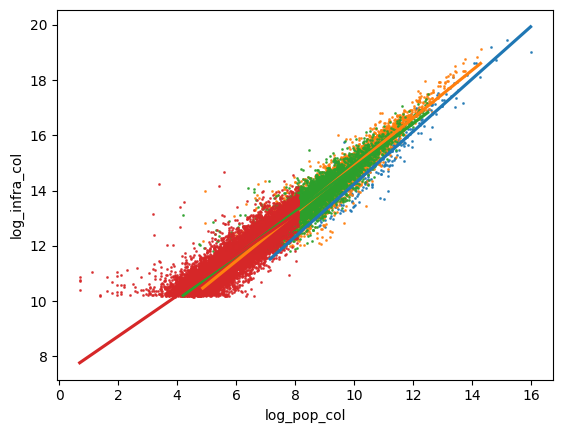

In [39]:
current_stock_col ='surface_Res_2020'
current_pop_col = 'CensusPop_20'
next_pop_col = 'ssp22030'
t = 2030

df_for_analysis = building_clean[['GEOID', 'State', 'NAMELSAD', 'ALAND', 'ua-to-place allocation factor_max', 'population_ua_max', 'weighted_HU_density_sqmi', 'city type', 
                                  'CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
                                  'avg_HU_size_Res_sqm','per_cap_mass_20', 'surface_Res_2020']]

df_for_2030 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2030, on ='GEOID')
building_clean = building_clean.merge(df_for_2030, on ='GEOID')
print(building_clean.shape)

In [40]:
df_for_analysis.columns

Index(['GEOID', 'State', 'NAMELSAD', 'ALAND',
       'ua-to-place allocation factor_max', 'population_ua_max',
       'weighted_HU_density_sqmi', 'city type', 'CensusPop_20', 'ssp22020',
       'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080',
       'ssp22090', 'ssp22100', 'avg_HU_size_Res_sqm', 'per_cap_mass_20',
       'surface_Res_2020', 'per_cap_mass_t1', 'per_cap_mass_at_2030',
       'surface_Res_at_2030', 'HU_density_sqmi_at_2030',
       'ua_population_at_2030', 'citytype_at_2030'],
      dtype='object')

#### For 2040

(31179, 27)
Initial dataframe:====
(31179, 27)
Shape of the dataframe for urban:====
(312, 27)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 27)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     2427.
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          2.28e-139
Time:                        17:45:12   Log-Likelihood:                -178.33
No. Observations:                 280   AIC:                             360.7
Df Residuals:                     278   BIC:                             367.9
Df Model:                           1                                         
Covariance Type:      

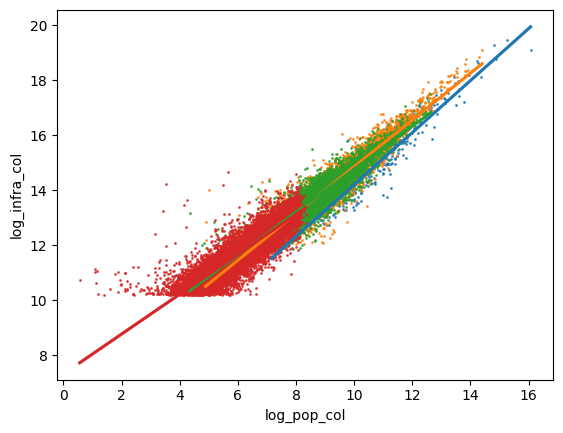

In [41]:
current_stock_col ='surface_Res_at_2030'
current_pop_col = 'ssp22030'
next_pop_col = 'ssp22040'
t = 2040

df_for_2040 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2040, on ='GEOID')
building_clean = building_clean.merge(df_for_2040, on ='GEOID')
print(building_clean.shape)

#### For 2050

(31179, 32)
Initial dataframe:====
(31179, 32)
Shape of the dataframe for urban:====
(312, 32)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 32)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     2396.
Date:                Tue, 02 Apr 2024   Prob (F-statistic):          1.12e-138
Time:                        17:46:20   Log-Likelihood:                -180.18
No. Observations:                 280   AIC:                             364.4
Df Residuals:                     278   BIC:                             371.6
Df Model:                           1                                         
Covariance Type:      

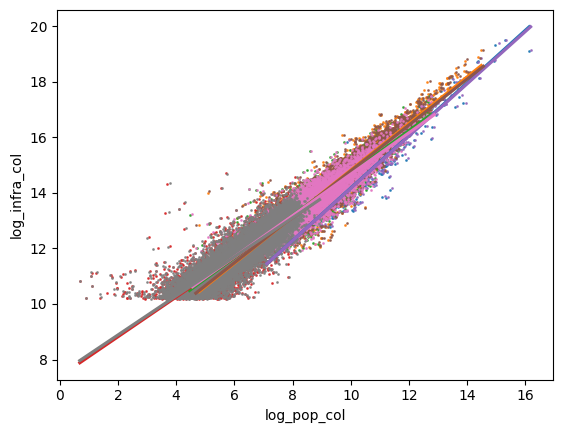

In [42]:
current_stock_col ='surface_Res_at_2040'
current_pop_col = 'ssp22040'
next_pop_col = 'ssp22050'
t = 2050

df_for_2050 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2050, on ='GEOID')
building_clean = building_clean.merge(df_for_2050, on ='GEOID')
print(building_clean.shape)

current_stock_col ='surface_Res_at_2050'
current_pop_col = 'ssp22050'
next_pop_col = 'ssp22060'
t = 2060

df_for_2060 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2060, on ='GEOID')
building_clean = building_clean.merge(df_for_2060, on ='GEOID')
print(building_clean.shape)

In [60]:
building_clean[['State', 'NAMELSAD', 'per_cap_mass_20', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050','per_cap_mass_at_2060',]]

,State,NAMELSAD,per_cap_mass_20,per_cap_mass_at_2030,per_cap_mass_at_2040,per_cap_mass_at_2050,per_cap_mass_at_2060
0,1.0,Ardmore town,268.172365,243.903333,226.656377,213.451194,202.009406
1,1.0,Mooresville town,365.552774,334.523277,310.018109,291.270362,274.635395
2,1.0,Somerville town,273.254252,270.220512,273.361553,280.120177,287.221460
3,1.0,Trinity town,282.925206,278.894239,278.255591,279.793967,280.011267
4,1.0,Goshen town,637.445878,616.445437,606.239815,599.010898,589.949286
...,...,...,...,...,...,...,...
31174,56.0,Westview Circle CDP,717.892109,699.275521,686.782313,677.306865,662.328864
31175,56.0,Whiting CDP,411.345015,399.187339,393.334021,385.446805,372.969290
31176,56.0,Wilson CDP,237.392302,213.621773,196.841268,182.619403,170.567410
31177,56.0,Woods Landing-Jelm CDP,305.204320,274.536305,248.524705,225.245025,203.580504


### plot per cap

(312, 80)


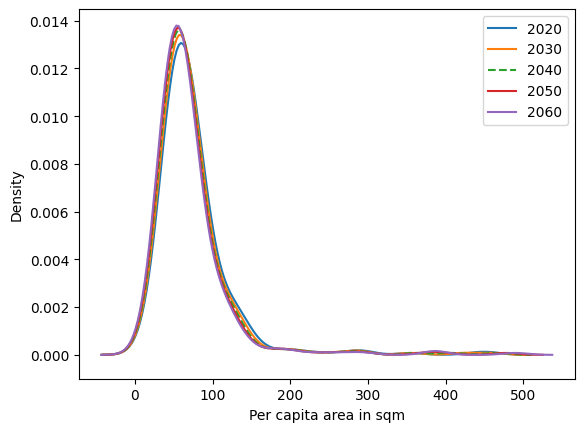

In [47]:
df_plot_city = building_clean[building_clean['city type'] == 'urban']
print(df_plot_city.shape)

sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_20')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2030')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2040', linestyle="--") 
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2050')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2060')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_70')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_80')
plt.ylim(-0.001, None)
plt.xlabel('Per capita area in sqm')
plt.legend(labels=['2020', '2030', '2040', '2050', '2060', '2070', '2080'])

(6887, 80)
Plotting 95 percentile values
(6542, 80)


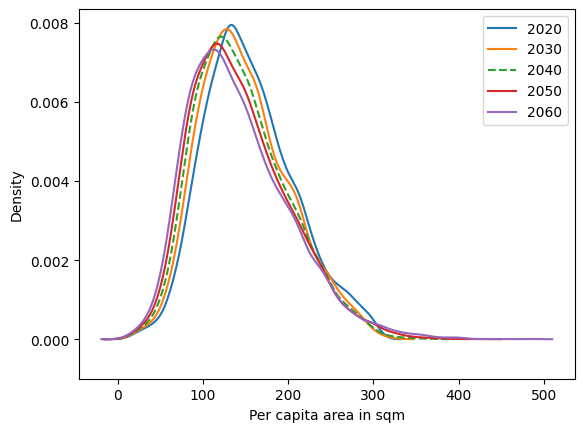

In [48]:
df_plot_city = building_clean[building_clean['city type'] == 'suburban']
print(df_plot_city.shape)
print("Plotting 95 percentile values")
q = df_plot_city['per_cap_mass_20'].quantile(0.95)
df_plot_city = df_plot_city[df_plot_city['per_cap_mass_20'] <= q]
print(df_plot_city.shape)

sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_20')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2030')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2040', linestyle="--") 
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2050')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2060')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_70')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_80')
plt.ylim(-0.001, None)
plt.xlabel('Per capita area in sqm')
plt.legend(labels=['2020', '2030', '2040', '2050', '2060', '2070', '2080'])


(5714, 80)
Plotting 95 percentile values
(5428, 80)


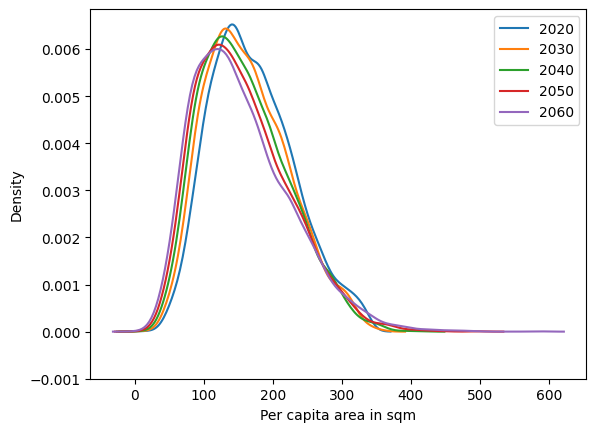

In [49]:
df_plot_city = building_clean[building_clean['city type'] == 'periurban']
print(df_plot_city.shape)
print("Plotting 95 percentile values")
q = df_plot_city['per_cap_mass_20'].quantile(0.95)
df_plot_city = df_plot_city[df_plot_city['per_cap_mass_20'] <= q]
print(df_plot_city.shape)
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_20')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2030')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2040') #, linestyle="--") 
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2050')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2060')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_70')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_80')

plt.ylim(-0.001, None)
plt.xlabel('Per capita area in sqm')
plt.legend(labels=['2020', '2030', '2040', '2050', '2060', '2070', '2080'])

(18266, 80)
Plotting 95 percentile values
(17352, 80)


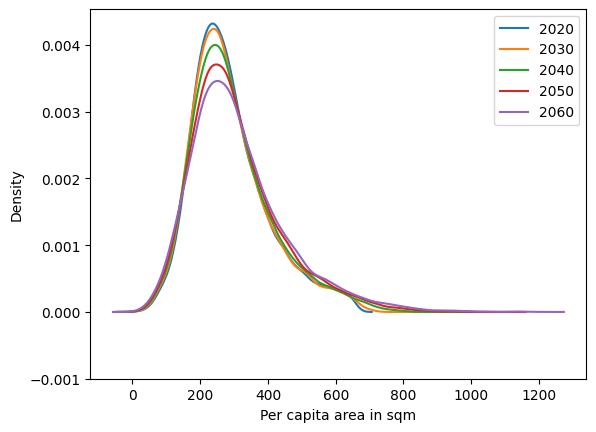

In [50]:
df_plot_city = building_clean[building_clean['city type'] == 'rural']
print(df_plot_city.shape)
print("Plotting 95 percentile values")
q = df_plot_city['per_cap_mass_20'].quantile(0.95)
df_plot_city = df_plot_city[df_plot_city['per_cap_mass_20'] <= q]
print(df_plot_city.shape)
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_20')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2030')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2040') #, linestyle="--") 
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2050')
sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_at_2060')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_70')
# sns.kdeplot(data=df_plot_city, x = 'per_cap_mass_80')

plt.ylim(-0.001, None)
plt.xlabel('Per capita area in sqm')
plt.legend(labels=['2020', '2030', '2040', '2050', '2060', '2070', '2080'])

In [54]:
# building_clean[['STATEFP','GEOID', 'NAMELSAD', 'surface_2020',
#        'surface_Res_2020', 'surface_nonRes_2020', 'volume_2020',
#        'landAreaSqkm', 'percent_built_surface', ' !!Total:', 'HUs_occupied',
#        'HUs_vaccant','HUs_Total', 'YB_>=_2020', 'YB_2010_2019',
#        'YB_2000_2009', 'YB_1980_1999', 'YB_1960_1979', 'YB_1940_1959',
#        'YB_<=_1939', 'Year_Built', 'Percent_Built', 'weighted_avg_age',
#        'State', 'REGION', 'ua-to-place allocation factor_max',
#        'population_ua_min', 'population_ua_max', 'CensusPop_20', 'city type',
#        'weighted_HU_density_sqmi', 'ssp22020', 'ssp22030', 'ssp22040',
#        'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
#        'avg_HU_size_sqm', 'HU_density_sqmile', 'avg_HU_size_Res_sqm',
#        'per_cap_mass_20', 'avg_HU_size_sqm_Res', 'per_cap_mass_at_2030',
#        'surface_Res_at_2030', 'HU_density_sqmi_at_2030',
#        'ua_population_at_2030', 'citytype_at_2030', 'per_cap_mass_at_2040',
#        'surface_Res_at_2040', 'HU_density_sqmi_at_2040',
#        'ua_population_at_2040', 'citytype_at_2040', 'per_cap_mass_at_2050',
#        'surface_Res_at_2050', 'HU_density_sqmi_at_2050',
#        'ua_population_at_2050', 'citytype_at_2050', 'per_cap_mass_at_2060',
#        'surface_Res_at_2060', 'HU_density_sqmi_at_2060',
#        'ua_population_at_2060', 'citytype_at_2060']].to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GHSL_AREA_VOL_data\buildings_output.csv')

In [ ]:
# # define whether shifts to urban or not
# new_col = 'city type'
# area_factor = 'ua-to-place allocation factor_max'
# msa_area_factor = 'cbsa20-to-place allocation factor'
# ua_population = 'population_ua_max'
# population = 'CensusPop_20'
# housingUnit_density = 'weighted_HU_density_sqmi'
# city_type = 'PCICBSA'
# df = df_0.copy()
# df[new_col] = " "

# # DEFINING URBAN < SUBURBAN < RURAL BASED ON THE RULES OF THE FOLLOWING LINK
# # Apply conditions for urban-suburban-rural
# # source: https://bjs.ojp.gov/content/pub/pdf/cusrancvs.pdf
# # Suburban and rural places will be further differentiated

# for i in df.index:
#     if df.loc[i,city_type] == 'Y':
#         if (df.loc[i, ua_population] >= 500000) & (df.loc[i, housingUnit_density] >= 3000) & (df.loc[i, area_factor] > 0):
#             df.loc[i, new_col] = 'urban'
#         else:
#             df.loc[i, new_col] = 'suburban'
            
#     elif (df.loc[i,city_type] == 'N') & (df.loc[i, area_factor] > 0):
#         if (df.loc[i, ua_population] >= 500000) & (df.loc[i, housingUnit_density] >= 4000):
#             df.loc[i, new_col] = 'urban'
#         else:
#             if (df.loc[i, 'tt_2_work_place'] <= df.loc[i, 'tt_2_work']):
#                 df.loc[i, new_col] = 'suburban'
#             else:
#                 df.loc[i, new_col] = 'periurban'
                
#     elif (df.loc[i,city_type] == 'N') & (df.loc[i, area_factor] <= 0):
#         if (df.loc[i, population] >= 50000) & (df.loc[i, housingUnit_density] >= 5000) | (
#             df.loc[i, population] >= 10000) & (df.loc[i, housingUnit_density] >= 10000):
            
#             df.loc[i, new_col] = 'urban'
#         else:
#             df.loc[i, new_col] = 'rural'          

#     else:
#         df.loc[i, new_col] = 'not enough data'